In [139]:
# CELL 1

from pathlib import Path

import pandas as pd
from IPython.display import display

from api.process_ai.process.pipeline.process_configs import get_process_config
from api.process_ai.process.core.registry_loader import load_registry, get_step_codes
from api.process_ai.process.core.validate import validate_events_df
from api.process_ai.process.core.features import build_case_feature_matrix, compute_baselines

In [140]:
# CELL 2

from pathlib import Path

PROCESS_KEY = "trucking"

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "api").exists() and (p / "model").exists():
            return p
    raise FileNotFoundError("Could not find project root")

def to_abs_path(path_like: str | Path, project_root: Path) -> Path:
    p = Path(path_like)
    return p if p.is_absolute() else (project_root / p).resolve()

PROJECT_ROOT = find_project_root()

cfg = get_process_config(PROCESS_KEY)
PROCESS_CODE = cfg.process_code

DATA_DIR = to_abs_path(cfg.data_dir, PROJECT_ROOT)
REGISTRY_DIR = to_abs_path(cfg.registry_dir, PROJECT_ROOT)
MODEL_DIR = to_abs_path(cfg.model_dir, PROJECT_ROOT)
REPORT_DIR = to_abs_path(cfg.report_dir, PROJECT_ROOT)

EVENTS_PATH = DATA_DIR / "events.csv"
CONTEXT_PATH = DATA_DIR / "cases_context.csv"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESS_KEY  :", PROCESS_KEY)
print("PROCESS_CODE :", PROCESS_CODE)
print("DATA_DIR     :", DATA_DIR)
print("REGISTRY_DIR :", REGISTRY_DIR)
print("MODEL_DIR    :", MODEL_DIR)
print("REPORT_DIR   :", REPORT_DIR)
print("EVENTS_PATH  :", EVENTS_PATH)
print("CONTEXT_PATH :", CONTEXT_PATH)

PROJECT_ROOT : D:\logistics_AI
PROCESS_KEY  : trucking
PROCESS_CODE : TRUCKING_DELIVERY_FLOW
DATA_DIR     : D:\logistics_AI\data\synth_optimal_3process_v1
REGISTRY_DIR : D:\logistics_AI\data\synth_optimal_3process_v1\registry
MODEL_DIR    : D:\logistics_AI\model\process_models
REPORT_DIR   : D:\logistics_AI\reports\trucking
EVENTS_PATH  : D:\logistics_AI\data\synth_optimal_3process_v1\events.csv
CONTEXT_PATH : D:\logistics_AI\data\synth_optimal_3process_v1\cases_context.csv


In [141]:
# CELL 3

registry = load_registry(REGISTRY_DIR, PROCESS_CODE)
step_codes = get_step_codes(registry)

print("Number of step codes:", len(step_codes))
print("Step codes:")
print(step_codes)

Number of step codes: 29
Step codes:
['STEP_001_DISPATCH_CREATED', 'STEP_002_CARRIER_TENDERED', 'STEP_003_TENDER_ACCEPTED', 'STEP_004_DRIVER_ASSIGNED', 'STEP_005_PICKUP_APPOINTMENT_SET', 'STEP_006_DRIVER_EN_ROUTE_PICKUP', 'STEP_007_ARRIVE_PICKUP', 'STEP_008_GATE_IN_PICKUP', 'STEP_009_WAIT_PICKUP', 'STEP_010_LOAD_START', 'STEP_011_LOAD_COMPLETE', 'STEP_012_DEPART_PICKUP', 'STEP_013_EN_ROUTE_HUB', 'STEP_014_ARRIVE_HUB', 'STEP_015_HUB_INBOUND_SCAN', 'STEP_016_HUB_SORT_COMPLETE', 'STEP_017_HUB_OUTBOUND_SCAN', 'STEP_018_LINEHAUL_START', 'STEP_019_IN_TRANSIT_LINEHAUL', 'STEP_020_ARRIVE_LASTMILE_DEPOT', 'STEP_021_LASTMILE_SORT_COMPLETE', 'STEP_022_ROUTE_PLANNED', 'STEP_023_OUT_FOR_DELIVERY', 'STEP_024_DELIVERY_ATTEMPT_1', 'STEP_025_DELIVERED_CONFIRMED', 'STEP_026_POD_UPLOADED', 'STEP_027_RETURN_TO_DEPOT', 'STEP_028_TRIP_CLOSEOUT', 'STEP_029_BILLING_COMPLETE']


In [142]:
# CELL 4

events_df = pd.read_csv(EVENTS_PATH)
cases_context_df = pd.read_csv(CONTEXT_PATH)

print("events_df columns:")
print(events_df.columns.tolist())

print("\ncases_context_df columns:")
print(cases_context_df.columns.tolist())

# Filter events theo process_code
if "process_code" in events_df.columns:
    events_df = events_df[events_df["process_code"].astype(str) == PROCESS_CODE].copy()

# Filter cases_context theo process_code nếu có,
# còn nếu không có thì lọc theo case_id xuất hiện trong events_df
if "process_code" in cases_context_df.columns:
    cases_context_df = cases_context_df[
        cases_context_df["process_code"].astype(str) == PROCESS_CODE
    ].copy()
elif "case_id" in cases_context_df.columns and "case_id" in events_df.columns:
    valid_case_ids = events_df["case_id"].astype(str).unique().tolist()
    cases_context_df = cases_context_df[
        cases_context_df["case_id"].astype(str).isin(valid_case_ids)
    ].copy()

print("\nevents_df shape:", events_df.shape)
print("cases_context_df shape:", cases_context_df.shape)

display(events_df.head())
display(cases_context_df.head())

events_df columns:
['process_code', 'case_id', 'step_code', 'start_time', 'end_time']

cases_context_df columns:
['case_id', 'distance_bucket', 'service_level', 'warehouse_code', 'hub_code', 'port_code', 'is_cross_border']

events_df shape: (348000, 5)
cases_context_df shape: (12000, 7)


,process_code,case_id,step_code,start_time,end_time
23,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_001_DISPATCH_CREATED,2025-06-28T20:32:31,2025-06-28T20:37:26
24,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_002_CARRIER_TENDERED,2025-06-28T20:37:26,2025-06-28T20:45:37
25,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_003_TENDER_ACCEPTED,2025-06-28T20:45:37,2025-06-28T20:52:10
26,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_004_DRIVER_ASSIGNED,2025-06-28T20:52:10,2025-06-28T21:05:01
27,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_005_PICKUP_APPOINTMENT_SET,2025-06-28T21:05:01,2025-06-28T21:16:31


,case_id,distance_bucket,service_level,warehouse_code,hub_code,port_code,is_cross_border
0,ORD_5260181590,2,1,WH_HCM_01,HUB_HA_NOI,NaN,0
1,ORD_6723268656,2,1,WH_DN_01,HUB_HA_NOI,NaN,0
2,ORD_6668364507,2,1,WH_HCM_02,HUB_TAN_BINH,NaN,0
3,ORD_1923969372,2,1,WH_HCM_01,HUB_BINH_TAN,HAI_PHONG,1
4,ORD_1636246770,2,2,WH_HN_01,HUB_TAN_BINH,NaN,0


In [143]:
# CELL 5

validated_events_df, validation_report = validate_events_df(
    events_df,
    process_code=PROCESS_CODE,
    valid_steps=step_codes,
    allow_unknown_steps=False,
)

print("validation_report.ok:", validation_report.ok)
print("validation_report.errors:")
print(validation_report.errors)
print("validation_report.warnings:")
print(validation_report.warnings)

print("validated_events_df shape:", validated_events_df.shape)
display(validated_events_df.head())

validation_report.ok: True
validation_report.errors:
[]
validation_report.warnings:
[]
validated_events_df shape: (348000, 6)


,process_code,case_id,step_code,start_time,end_time,duration_sec
23,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_001_DISPATCH_CREATED,2025-06-28 20:32:31,2025-06-28 20:37:26,295.0
24,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_002_CARRIER_TENDERED,2025-06-28 20:37:26,2025-06-28 20:45:37,491.0
25,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_003_TENDER_ACCEPTED,2025-06-28 20:45:37,2025-06-28 20:52:10,393.0
26,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_004_DRIVER_ASSIGNED,2025-06-28 20:52:10,2025-06-28 21:05:01,771.0
27,TRUCKING_DELIVERY_FLOW,ORD_5260181590,STEP_005_PICKUP_APPOINTMENT_SET,2025-06-28 21:05:01,2025-06-28 21:16:31,690.0


In [144]:
# CELL 6

feature_df, feature_schema, feature_report = build_case_feature_matrix(
    validated_events_df,
    step_codes=step_codes,
    cases_context_df=cases_context_df,
    include_context_numeric=False,
)

print("feature_df shape:", feature_df.shape)
print("feature_schema keys:", list(feature_schema.keys()))
print("feature_report:", feature_report)

display(feature_df.head())

feature_df shape: (12000, 38)
feature_schema keys: ['step_codes', 'step_feature_cols', 'all_feature_cols']
feature_report: FeatureBuildReport(cases=12000, dropped_cases=0, repeated_case_count=0, missing_step_cases=0)


,STEP_001_DISPATCH_CREATED_duration_min,STEP_002_CARRIER_TENDERED_duration_min,STEP_003_TENDER_ACCEPTED_duration_min,STEP_004_DRIVER_ASSIGNED_duration_min,STEP_005_PICKUP_APPOINTMENT_SET_duration_min,STEP_006_DRIVER_EN_ROUTE_PICKUP_duration_min,STEP_007_ARRIVE_PICKUP_duration_min,STEP_008_GATE_IN_PICKUP_duration_min,STEP_009_WAIT_PICKUP_duration_min,STEP_010_LOAD_START_duration_min,...,STEP_029_BILLING_COMPLETE_duration_min,total_process_time_min,max_step_duration_min,mean_step_duration_min,std_step_duration_min,step_count_present,missing_step_count,missing_step_flag,repeated_step_total,repeated_step_flag
case_id,,,,,,,,,,,,,,,,,,,,,
ORD_0000312750,7.666667,11.733333,7.650000,6.516667,11.116667,10.283333,18.066667,21.450000,6.166667,16.150000,...,16.616667,640.433333,136.850000,22.083908,26.798659,29,0,0,0,0
ORD_0000434015,7.383333,18.466667,6.066667,11.750000,6.183333,18.833333,9.050000,23.833333,5.766667,26.500000,...,5.050000,757.833333,148.683333,26.132184,32.796316,29,0,0,0,0
ORD_0003576909,9.100000,37.000000,13.750000,14.333333,10.850000,13.350000,11.683333,6.133333,17.683333,43.433333,...,4.466667,867.483333,132.866667,29.913218,34.703325,29,0,0,0,0
ORD_0003662246,10.316667,90.666667,8.333333,16.950000,9.466667,5.166667,6.916667,6.516667,15.483333,23.366667,...,11.733333,735.716667,151.050000,25.369540,30.582224,29,0,0,0,0
ORD_0004464291,2.716667,4.983333,2.966667,6.766667,11.066667,27.833333,11.133333,14.383333,4.166667,11.583333,...,11.333333,1666.116667,704.483333,57.452299,144.495436,29,0,0,0,0


In [145]:
# CELL 7

print("Feature columns:")
print(feature_df.columns.tolist())

print("\nFeature schema:")
print(feature_schema)

print("\nFeature report:")
print(feature_report)

display(feature_df.describe(include="all").T.head(20))

Feature columns:
['STEP_001_DISPATCH_CREATED_duration_min', 'STEP_002_CARRIER_TENDERED_duration_min', 'STEP_003_TENDER_ACCEPTED_duration_min', 'STEP_004_DRIVER_ASSIGNED_duration_min', 'STEP_005_PICKUP_APPOINTMENT_SET_duration_min', 'STEP_006_DRIVER_EN_ROUTE_PICKUP_duration_min', 'STEP_007_ARRIVE_PICKUP_duration_min', 'STEP_008_GATE_IN_PICKUP_duration_min', 'STEP_009_WAIT_PICKUP_duration_min', 'STEP_010_LOAD_START_duration_min', 'STEP_011_LOAD_COMPLETE_duration_min', 'STEP_012_DEPART_PICKUP_duration_min', 'STEP_013_EN_ROUTE_HUB_duration_min', 'STEP_014_ARRIVE_HUB_duration_min', 'STEP_015_HUB_INBOUND_SCAN_duration_min', 'STEP_016_HUB_SORT_COMPLETE_duration_min', 'STEP_017_HUB_OUTBOUND_SCAN_duration_min', 'STEP_018_LINEHAUL_START_duration_min', 'STEP_019_IN_TRANSIT_LINEHAUL_duration_min', 'STEP_020_ARRIVE_LASTMILE_DEPOT_duration_min', 'STEP_021_LASTMILE_SORT_COMPLETE_duration_min', 'STEP_022_ROUTE_PLANNED_duration_min', 'STEP_023_OUT_FOR_DELIVERY_duration_min', 'STEP_024_DELIVERY_ATTEMPT_

,count,mean,std,min,25%,50%,75%,max
STEP_001_DISPATCH_CREATED_duration_min,12000.0,11.596114,6.883907,1.016667,6.866667,9.966667,14.404167,98.183333
STEP_002_CARRIER_TENDERED_duration_min,12000.0,11.674674,7.050284,1.183333,6.883333,10.058333,14.583333,101.733333
STEP_003_TENDER_ACCEPTED_duration_min,12000.0,11.839271,7.080018,1.266667,7.095833,10.166667,14.683333,108.383333
STEP_004_DRIVER_ASSIGNED_duration_min,12000.0,11.641764,6.948730,1.283333,6.883333,10.050000,14.466667,89.350000
STEP_005_PICKUP_APPOINTMENT_SET_duration_min,12000.0,11.717326,6.966395,1.133333,6.900000,10.066667,14.666667,79.883333
STEP_006_DRIVER_EN_ROUTE_PICKUP_duration_min,12000.0,12.651421,8.653063,1.216667,6.850000,10.300000,15.833333,113.033333
STEP_007_ARRIVE_PICKUP_duration_min,12000.0,11.740525,6.902378,1.233333,6.966667,10.083333,14.550000,69.633333
STEP_008_GATE_IN_PICKUP_duration_min,12000.0,11.524547,6.861427,1.233333,6.816667,9.991667,14.350000,86.616667
STEP_009_WAIT_PICKUP_duration_min,12000.0,11.009917,7.222274,1.116667,6.300000,9.350000,13.633333,128.016667
STEP_010_LOAD_START_duration_min,12000.0,23.435829,14.363486,2.583333,13.816667,20.166667,28.983333,239.666667


In [146]:
# CELL 8

baselines = compute_baselines(
    feature_df,
    step_codes=step_codes,
)

print("Baseline keys:")
print(baselines.keys())

print("\nStep baseline sample:")
display(pd.DataFrame(baselines.get("steps", {})).T.head())

Baseline keys:
dict_keys(['steps', 'total_process_time_min', 'n_cases_for_baseline'])

Step baseline sample:


,mean,std,p95,p99,missing_rate
STEP_001_DISPATCH_CREATED,11.596114,6.883620,24.833333,35.900000,0.0
STEP_002_CARRIER_TENDERED,11.674674,7.049990,24.700833,36.483667,0.0
STEP_003_TENDER_ACCEPTED,11.839271,7.079723,25.284167,37.067000,0.0
STEP_004_DRIVER_ASSIGNED,11.641764,6.948441,24.750000,35.933500,0.0
STEP_005_PICKUP_APPOINTMENT_SET,11.717326,6.966105,24.900000,35.951000,0.0


In [147]:
# CELL 9

case_counts = (
    validated_events_df.groupby("case_id")
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
)

print("Number of unique cases:", case_counts["case_id"].nunique())
display(case_counts.head(10))

Number of unique cases: 12000


,case_id,event_count
0,ORD_0000312750,29
1,ORD_0000434015,29
2,ORD_0003576909,29
3,ORD_0003662246,29
4,ORD_0004464291,29
5,ORD_0005053777,29
6,ORD_0005511584,29
7,ORD_0006530047,29
8,ORD_0010627475,29
9,ORD_0010926443,29


In [148]:
# CELL 10

step_counts = (
    validated_events_df["step_code"]
    .value_counts(dropna=False)
    .reset_index()
)
step_counts.columns = ["step_code", "count"]

display(step_counts)

,step_code,count
0,STEP_001_DISPATCH_CREATED,12000
1,STEP_002_CARRIER_TENDERED,12000
2,STEP_003_TENDER_ACCEPTED,12000
3,STEP_004_DRIVER_ASSIGNED,12000
4,STEP_005_PICKUP_APPOINTMENT_SET,12000
5,STEP_006_DRIVER_EN_ROUTE_PICKUP,12000
6,STEP_007_ARRIVE_PICKUP,12000
7,STEP_008_GATE_IN_PICKUP,12000
8,STEP_009_WAIT_PICKUP,12000
9,STEP_010_LOAD_START,12000


In [149]:
# CELL 11

missing_step_cases = []

total_cases = feature_df.index.astype(str).nunique()

for s in step_codes:
    case_has_step = (
        validated_events_df.loc[validated_events_df["step_code"] == s, "case_id"]
        .astype(str)
        .unique()
    )

    missing_count = total_cases - len(case_has_step)

    missing_step_cases.append({
        "step_code": s,
        "missing_case_count": missing_count,
    })

missing_step_df = pd.DataFrame(missing_step_cases).sort_values(
    "missing_case_count", ascending=False
)

display(missing_step_df)

,step_code,missing_case_count
0,STEP_001_DISPATCH_CREATED,0
1,STEP_002_CARRIER_TENDERED,0
2,STEP_003_TENDER_ACCEPTED,0
3,STEP_004_DRIVER_ASSIGNED,0
4,STEP_005_PICKUP_APPOINTMENT_SET,0
5,STEP_006_DRIVER_EN_ROUTE_PICKUP,0
6,STEP_007_ARRIVE_PICKUP,0
7,STEP_008_GATE_IN_PICKUP,0
8,STEP_009_WAIT_PICKUP,0
9,STEP_010_LOAD_START,0


In [150]:
# CELL 12

print("Final check:")
print("- Registry loaded:", registry is not None)
print("- Step codes loaded:", len(step_codes) > 0)
print("- Events validated:", validation_report.ok)
print("- Feature matrix ready:", not feature_df.empty)
print("- Baselines computed:", bool(baselines))

Final check:
- Registry loaded: True
- Step codes loaded: True
- Events validated: True
- Feature matrix ready: True
- Baselines computed: True


In [151]:
# CELL 13

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

REPORT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY = "#1f4e79"
SECONDARY = "#5b9bd5"
ACCENT = "#9dc3e6"
GRID = "#d9d9d9"
TEXT = "#222222"

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT
plt.rcParams["text.color"] = TEXT
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

def pretty_step_label(x: str) -> str:
    x = str(x)
    x = x.replace("STEP_", "")
    parts = x.split("_", 1)
    if len(parts) == 2 and parts[0].isdigit():
        x = parts[1]
    x = x.replace("_", " ").title()
    return x[:32] + "..." if len(x) > 32 else x

def style_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.grid(axis=grid_axis, color=GRID, linestyle="-", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def save_and_show(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", path)

In [152]:
# CELL 14

summary_rows = []

summary_rows.append({
    "metric": "process_code",
    "value": PROCESS_CODE,
})

summary_rows.append({
    "metric": "num_step_codes",
    "value": len(step_codes),
})

summary_rows.append({
    "metric": "validated_event_rows",
    "value": int(len(validated_events_df)),
})

summary_rows.append({
    "metric": "num_cases",
    "value": int(feature_df.shape[0]),
})

summary_rows.append({
    "metric": "num_features",
    "value": int(feature_df.shape[1]),
})

summary_rows.append({
    "metric": "dropped_cases",
    "value": int(getattr(feature_report, "dropped_cases", 0)),
})

summary_rows.append({
    "metric": "repeated_case_count",
    "value": int(getattr(feature_report, "repeated_case_count", 0)),
})

summary_rows.append({
    "metric": "missing_step_cases",
    "value": int(getattr(feature_report, "missing_step_cases", 0)),
})

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,metric,value
0,process_code,TRUCKING_DELIVERY_FLOW
1,num_step_codes,29
2,validated_event_rows,348000
3,num_cases,12000
4,num_features,38
5,dropped_cases,0
6,repeated_case_count,0
7,missing_step_cases,0


In [153]:
# CELL 15

step_duration_summary_df = (
    validated_events_df.assign(
        start_time=pd.to_datetime(validated_events_df["start_time"]),
        end_time=pd.to_datetime(validated_events_df["end_time"]),
    )
    .assign(duration_min=lambda d: (d["end_time"] - d["start_time"]).dt.total_seconds() / 60.0)
    .groupby("step_code")["duration_min"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

step_duration_summary_df["step_label"] = step_duration_summary_df["step_code"].map(pretty_step_label)
step_duration_summary_df = step_duration_summary_df.sort_values("mean", ascending=False)

display(step_duration_summary_df)

,step_code,count,mean,median,max,step_label
18,STEP_019_IN_TRANSIT_LINEHAUL,12000,156.123342,126.008333,1705.733333,In Transit Linehaul
17,STEP_018_LINEHAUL_START,12000,153.502497,125.783333,1440.000000,Linehaul Start
12,STEP_013_EN_ROUTE_HUB,12000,150.232222,122.933333,1757.266667,En Route Hub
23,STEP_024_DELIVERY_ATTEMPT_1,12000,34.745050,29.691667,264.400000,Delivery Attempt 1
22,STEP_023_OUT_FOR_DELIVERY,12000,34.583553,29.783333,312.216667,Out For Delivery
9,STEP_010_LOAD_START,12000,23.435829,20.166667,239.666667,Load Start
25,STEP_026_POD_UPLOADED,12000,23.151231,19.816667,199.933333,Pod Uploaded
10,STEP_011_LOAD_COMPLETE,12000,23.123656,19.866667,278.216667,Load Complete
20,STEP_021_LASTMILE_SORT_COMPLETE,12000,14.163571,12.083333,135.750000,Lastmile Sort Complete
15,STEP_016_HUB_SORT_COMPLETE,12000,14.080071,11.966667,146.966667,Hub Sort Complete


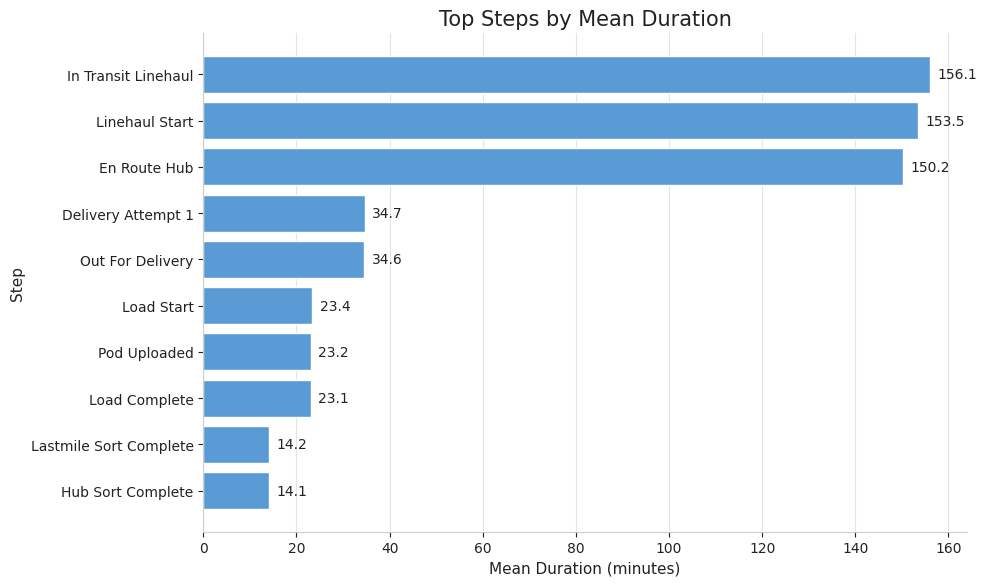

Saved: D:\logistics_AI\reports\trucking\trucking_top_step_mean_duration.png


In [154]:
# CELL 16

top_mean_df = step_duration_summary_df.head(10).copy().sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_mean_df["step_label"], top_mean_df["mean"], color=SECONDARY, edgecolor="white")
ax.set_title("Top Steps by Mean Duration")
ax.set_xlabel("Mean Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + max(top_mean_df["mean"]) * 0.01, bar.get_y() + bar.get_height()/2, f"{w:.1f}",
            va="center", ha="left", fontsize=10)

mean_duration_path = REPORT_DIR / f"{PROCESS_KEY}_top_step_mean_duration.png"
save_and_show(fig, mean_duration_path)

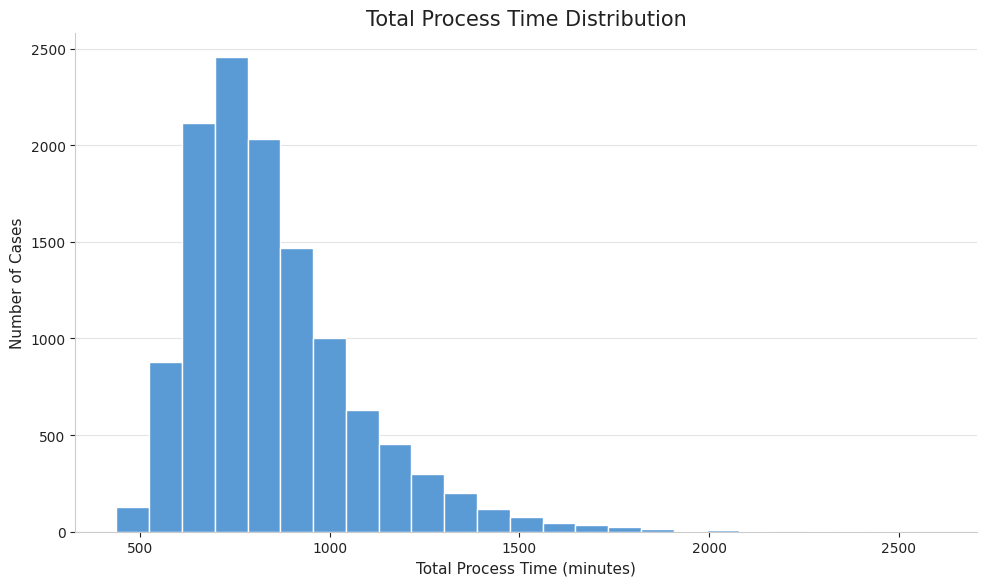

Saved: D:\logistics_AI\reports\trucking\trucking_total_process_time_hist.png


In [155]:
# CELL 17

if "total_process_time_min" in feature_df.columns:
    total_time_series = feature_df["total_process_time_min"].copy()
else:
    step_duration_cols = [c for c in feature_df.columns if str(c).endswith("_duration_min")]
    total_time_series = feature_df[step_duration_cols].sum(axis=1)

total_time_df = pd.DataFrame({
    "case_id": feature_df.index.astype(str),
    "total_process_time_min": total_time_series.values,
}).sort_values("total_process_time_min", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(total_time_df["total_process_time_min"], bins=25, color=SECONDARY, edgecolor="white")
ax.set_title("Total Process Time Distribution")
ax.set_xlabel("Total Process Time (minutes)")
ax.set_ylabel("Number of Cases")
style_axes(ax, grid_axis="y")

total_time_hist_path = REPORT_DIR / f"{PROCESS_KEY}_total_process_time_hist.png"
save_and_show(fig, total_time_hist_path)

In [156]:
# CELL 18

baseline_step_df = pd.DataFrame(baselines.get("steps", {})).T.reset_index()
baseline_step_df = baseline_step_df.rename(columns={"index": "step_code"})

for col in ["mean", "std", "p95", "count"]:
    if col in baseline_step_df.columns:
        baseline_step_df[col] = pd.to_numeric(baseline_step_df[col], errors="coerce")

baseline_step_df["step_label"] = baseline_step_df["step_code"].map(pretty_step_label)
baseline_step_df = baseline_step_df.sort_values("p95", ascending=False)

display(baseline_step_df)

,step_code,mean,std,p95,p99,missing_rate,step_label
18,STEP_019_IN_TRANSIT_LINEHAUL,156.123342,115.283168,363.264167,577.193333,0.0,In Transit Linehaul
17,STEP_018_LINEHAUL_START,153.502497,106.690507,350.752500,553.310000,0.0,Linehaul Start
12,STEP_013_EN_ROUTE_HUB,150.232222,103.004302,343.422500,538.457167,0.0,En Route Hub
23,STEP_024_DELIVERY_ATTEMPT_1,34.745050,20.934855,74.485833,109.100167,0.0,Delivery Attempt 1
22,STEP_023_OUT_FOR_DELIVERY,34.583553,20.810673,73.484167,105.601833,0.0,Out For Delivery
9,STEP_010_LOAD_START,23.435829,14.362888,49.884167,73.767333,0.0,Load Start
25,STEP_026_POD_UPLOADED,23.151231,13.949761,49.336667,73.416833,0.0,Pod Uploaded
10,STEP_011_LOAD_COMPLETE,23.123656,14.049086,48.883333,71.301667,0.0,Load Complete
15,STEP_016_HUB_SORT_COMPLETE,14.080071,8.985829,30.335000,45.050167,0.0,Hub Sort Complete
20,STEP_021_LASTMILE_SORT_COMPLETE,14.163571,8.794673,30.067500,45.652000,0.0,Lastmile Sort Complete


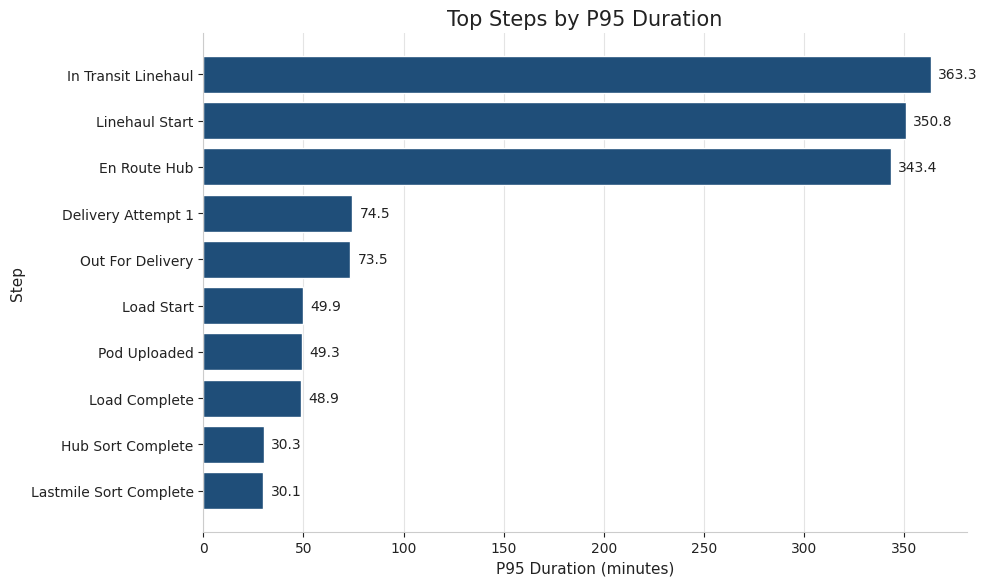

Saved: D:\logistics_AI\reports\trucking\trucking_top_step_p95.png


In [157]:
# CELL 19

top_p95_df = baseline_step_df.head(10).copy().sort_values("p95", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_p95_df["step_label"], top_p95_df["p95"], color=PRIMARY, edgecolor="white")
ax.set_title("Top Steps by P95 Duration")
ax.set_xlabel("P95 Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + max(top_p95_df["p95"]) * 0.01, bar.get_y() + bar.get_height()/2, f"{w:.1f}",
            va="center", ha="left", fontsize=10)

baseline_p95_path = REPORT_DIR / f"{PROCESS_KEY}_top_step_p95.png"
save_and_show(fig, baseline_p95_path)

In [158]:
# CELL 20

missing_step_cases = []
total_cases = feature_df.index.astype(str).nunique()

for s in step_codes:
    case_has_step = (
        validated_events_df.loc[validated_events_df["step_code"] == s, "case_id"]
        .astype(str)
        .nunique()
    )
    missing_step_cases.append({
        "step_code": s,
        "missing_case_count": total_cases - case_has_step,
    })

missing_step_df = pd.DataFrame(missing_step_cases).sort_values("missing_case_count", ascending=False)
missing_step_df["step_label"] = missing_step_df["step_code"].map(pretty_step_label)

display(missing_step_df)

if missing_step_df["missing_case_count"].max() > 0:
    top_missing_df = missing_step_df.head(10).copy().sort_values("missing_case_count", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_missing_df["step_label"], top_missing_df["missing_case_count"], color=ACCENT, edgecolor="white")
    ax.set_title("Top Steps with Missing Cases")
    ax.set_xlabel("Number of Missing Cases")
    ax.set_ylabel("Step")
    style_axes(ax, grid_axis="x")

    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(top_missing_df["missing_case_count"].max(), 1) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{int(w)}", va="center", ha="left", fontsize=10)

    missing_step_path = REPORT_DIR / f"{PROCESS_KEY}_top_missing_step_cases.png"
    save_and_show(fig, missing_step_path)
else:
    print("No missing-step issue detected. Skipping missing-step chart.")

,step_code,missing_case_count,step_label
0,STEP_001_DISPATCH_CREATED,0,Dispatch Created
1,STEP_002_CARRIER_TENDERED,0,Carrier Tendered
2,STEP_003_TENDER_ACCEPTED,0,Tender Accepted
3,STEP_004_DRIVER_ASSIGNED,0,Driver Assigned
4,STEP_005_PICKUP_APPOINTMENT_SET,0,Pickup Appointment Set
5,STEP_006_DRIVER_EN_ROUTE_PICKUP,0,Driver En Route Pickup
6,STEP_007_ARRIVE_PICKUP,0,Arrive Pickup
7,STEP_008_GATE_IN_PICKUP,0,Gate In Pickup
8,STEP_009_WAIT_PICKUP,0,Wait Pickup
9,STEP_010_LOAD_START,0,Load Start


No missing-step issue detected. Skipping missing-step chart.


In [159]:
# CELL 21

display(
    step_duration_summary_df.sort_values("median", ascending=False).head(10)[
        ["step_code", "count", "mean", "median", "max"]
    ]
)

,step_code,count,mean,median,max
18,STEP_019_IN_TRANSIT_LINEHAUL,12000,156.123342,126.008333,1705.733333
17,STEP_018_LINEHAUL_START,12000,153.502497,125.783333,1440.000000
12,STEP_013_EN_ROUTE_HUB,12000,150.232222,122.933333,1757.266667
22,STEP_023_OUT_FOR_DELIVERY,12000,34.583553,29.783333,312.216667
23,STEP_024_DELIVERY_ATTEMPT_1,12000,34.745050,29.691667,264.400000
9,STEP_010_LOAD_START,12000,23.435829,20.166667,239.666667
10,STEP_011_LOAD_COMPLETE,12000,23.123656,19.866667,278.216667
25,STEP_026_POD_UPLOADED,12000,23.151231,19.816667,199.933333
20,STEP_021_LASTMILE_SORT_COMPLETE,12000,14.163571,12.083333,135.750000
15,STEP_016_HUB_SORT_COMPLETE,12000,14.080071,11.966667,146.966667


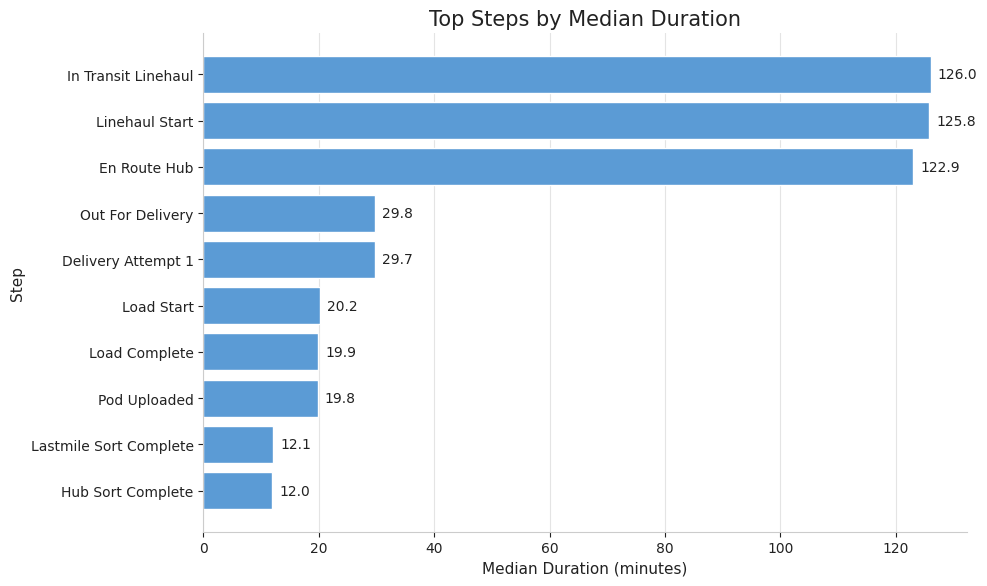

Saved: D:\logistics_AI\reports\trucking\trucking_top_step_median_duration.png


In [160]:
# CELL 22

top_median_df = (
    step_duration_summary_df.sort_values("median", ascending=False)
    .head(10)
    .copy()
    .sort_values("median", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_median_df["step_label"], top_median_df["median"], color=SECONDARY, edgecolor="white")
ax.set_title("Top Steps by Median Duration")
ax.set_xlabel("Median Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + max(top_median_df["median"]) * 0.01, bar.get_y() + bar.get_height()/2, f"{w:.1f}",
            va="center", ha="left", fontsize=10)

step_median_path = REPORT_DIR / f"{PROCESS_KEY}_top_step_median_duration.png"
save_and_show(fig, step_median_path)

In [161]:
# CELL 23

summary_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_summary_metrics.csv", index=False)
total_time_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_total_process_time.csv", index=False)
baseline_step_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_baseline_steps.csv", index=False)
step_duration_summary_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_step_duration_summary.csv", index=False)
missing_step_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_missing_steps.csv", index=False)

print("Saved CSV files to:", REPORT_DIR)

Saved CSV files to: D:\logistics_AI\reports\trucking


In [162]:
# CELL 24

generated_files = [
    REPORT_DIR / f"{PROCESS_KEY}_top_step_mean_duration.png",
    REPORT_DIR / f"{PROCESS_KEY}_total_process_time_hist.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_p95.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_median_duration.png",
    REPORT_DIR / f"{PROCESS_KEY}_summary_metrics.csv",
    REPORT_DIR / f"{PROCESS_KEY}_total_process_time.csv",
    REPORT_DIR / f"{PROCESS_KEY}_baseline_steps.csv",
    REPORT_DIR / f"{PROCESS_KEY}_step_duration_summary.csv",
    REPORT_DIR / f"{PROCESS_KEY}_missing_steps.csv",
]

optional_missing_chart = REPORT_DIR / f"{PROCESS_KEY}_top_missing_step_cases.png"
if optional_missing_chart.exists():
    generated_files.append(optional_missing_chart)

for f in generated_files:
    print(f.exists(), "-", f)

True - D:\logistics_AI\reports\trucking\trucking_top_step_mean_duration.png
True - D:\logistics_AI\reports\trucking\trucking_total_process_time_hist.png
True - D:\logistics_AI\reports\trucking\trucking_top_step_p95.png
True - D:\logistics_AI\reports\trucking\trucking_top_step_median_duration.png
True - D:\logistics_AI\reports\trucking\trucking_summary_metrics.csv
True - D:\logistics_AI\reports\trucking\trucking_total_process_time.csv
True - D:\logistics_AI\reports\trucking\trucking_baseline_steps.csv
True - D:\logistics_AI\reports\trucking\trucking_step_duration_summary.csv
True - D:\logistics_AI\reports\trucking\trucking_missing_steps.csv
True - D:\logistics_AI\reports\trucking\trucking_top_missing_step_cases.png
